# Long-lived eddies: depth-following PV-gradient case studies

This is the depth-resolved counterpart of `long_eddies.ipynb`. It loads the cached depth-following tables rather than recalculating ellipse means. Each colour represents the same fixed cached depth in every time-series panel and on the map. Values are selected directly at those model levels: no vertical interpolation or extrapolation is performed. Blue and orange background shading use the depth-averaged snapshot classification so each time has one unambiguous regime.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
import seacofs_tilt_tools as tilt
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

## Settings and cached data

In [ ]:
# Choose positions in the exact-depth catalogue displayed in the next cell.
# Indices 7 and 20 are approximately 48.90 m and 660.81 m.
DEPTH_LEVEL_INDICES = (7, 20)
DOMINANCE_FACTOR = 2.0
N_PER_POLARITY = 6

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
snapshot_df = tilt.add_pv_gradient_terms(source='depth_snapshot')
depth_df = tilt.add_pv_gradient_terms(source='depth')
AVAILABLE_DEPTHS_M = np.sort(depth_df.Depth.dropna().unique())
if any(i < 0 or i >= len(AVAILABLE_DEPTHS_M) for i in DEPTH_LEVEL_INDICES):
    raise IndexError(f'Depth indices must be between 0 and {len(AVAILABLE_DEPTHS_M)-1}')
TARGET_DEPTHS_M = tuple(AVAILABLE_DEPTHS_M[list(DEPTH_LEVEL_INDICES)])

assert not snapshot_df.duplicated(['Eddy', 'Day']).any()
assert not depth_df.duplicated(['Eddy', 'Day', 'Depth']).any()
print(f'{len(snapshot_df):,} snapshots; {len(depth_df):,} depth rows')
print('Selected exact depths:', ', '.join(f'{z:.2f} m' for z in TARGET_DEPTHS_M))

## Select the longest-lived eddies

Selection uses one row per eddy-day. If `Age` is unavailable, observed day span is used.

In [ ]:
depth_catalogue = pd.DataFrame({
    'depth_index': np.arange(len(AVAILABLE_DEPTHS_M)),
    'Depth_m': AVAILABLE_DEPTHS_M,
})
depth_catalogue['selected'] = depth_catalogue.depth_index.isin(DEPTH_LEVEL_INDICES)
display(depth_catalogue)

In [3]:
if 'Age' in snapshot_df:
    lifetime = snapshot_df.groupby(['Cyc', 'Eddy']).Age.first()
else:
    lifetime = snapshot_df.groupby(['Cyc', 'Eddy']).Day.agg(np.ptp)
selected_ids = (lifetime.groupby(level='Cyc').nlargest(N_PER_POLARITY)
                .index.get_level_values('Eddy').unique())
selected = snapshot_df[snapshot_df.Eddy.isin(selected_ids)].copy()
display(lifetime.loc[lifetime.index.get_level_values('Eddy').isin(selected_ids)]
        .rename('lifetime_days').reset_index().sort_values(['Cyc', 'lifetime_days'], ascending=[True, False]))

,Cyc,Eddy,lifetime_days
3,AE,1015,462
0,AE,184,437
4,AE,1260,322
5,AE,1741,261
1,AE,356,244
2,AE,969,244
11,CE,2297,201
9,CE,751,189
8,CE,476,184
7,CE,397,183


## Select exact cached depth levels

Rows are taken directly from `depth_df` at the selected fixed depths. All cached variables—including PV-gradient magnitudes, directions and dominance—remain unchanged; there is no interpolation, extrapolation or reconstruction.

In [4]:
def fixed_depth_track(eddy, target_depths=TARGET_DEPTHS_M):
    target_depths = tuple(target_depths)
    missing = [z for z in target_depths if not np.isin(z, AVAILABLE_DEPTHS_M)]
    if missing:
        raise ValueError(
            f'Selected depths are not exact cached levels: {missing}. '
            'Choose depths from AVAILABLE_DEPTHS_M.'
        )
    out = (depth_df.loc[
        depth_df.Eddy.eq(eddy) & depth_df.Depth.isin(target_depths)
    ].copy()
        .rename(columns={'Depth': 'TargetDepth'})
        .sort_values(['TargetDepth', 'Day'])
        .reset_index(drop=True))
    if out.empty:
        raise ValueError(f'Eddy {eddy} has no rows at the selected depths')
    return out

## Depth-resolved time plot

The original tilt/shear/ellipse/delta-theta additions are deliberately omitted here. The map uses depth colour rather than eddy age because depth is the comparison of interest.

In [22]:
def time_plot_depth(eddy, snapshot_data=snapshot_df, grid=grid, clip_outliers=True):
    snap = snapshot_data[snapshot_data.Eddy.eq(eddy)].sort_values('Day').copy()
    if snap.empty:
        raise ValueError(f'Eddy {eddy} is not present in snapshot_data')
    prof = fixed_depth_track(eddy).sort_values(
        ['TargetDepth', 'Day'],
        ascending=[False, True]
    )
    t0 = snap.Day.iloc[0]
    snap['t'] = snap.Day - t0
    prof['t'] = prof.Day - t0
    cyc = snap.Cyc.iloc[0]

    # depth_colors = dict(zip(TARGET_DEPTHS_M, plt.cm.viridis(np.linspace(.08, .92, len(TARGET_DEPTHS_M)))))
    if cyc == 'AE':
        depth_colors = dict(zip(TARGET_DEPTHS_M, plt.cm.Reds_r(np.linspace(.02, .52, len(TARGET_DEPTHS_M)))))
    else:
        depth_colors = dict(zip(TARGET_DEPTHS_M, plt.cm.Blues_r(np.linspace(.02, .52, len(TARGET_DEPTHS_M)))))
    PLAN_COLOR, TOPO_COLOR = 'tab:blue', 'tab:orange'
    threshold = np.log(DOMINANCE_FACTOR)
    planetary = snap.topo_plan_ratio_smooth <= -threshold
    topographic = snap.topo_plan_ratio_smooth >= threshold

    fig = plt.figure(figsize=(13, 11))
    gs = fig.add_gridspec(6, 2, width_ratios=[2.2, 1])
    axs = [fig.add_subplot(gs[i, 0]) for i in range(6)]
    axm = fig.add_subplot(gs[:, 1])
    for ax in axs:
        for t in snap.loc[planetary, 't']:
            ax.axvspan(t-.5, t+.5, color=PLAN_COLOR, alpha=.2, lw=0)
        for t in snap.loc[topographic, 't']:
            ax.axvspan(t-.5, t+.5, color=TOPO_COLOR, alpha=.2, lw=0)

    axs[0].plot(snap.t, snap.TiltDis, color='magenta', lw=1.7)
    axs[0].set_ylabel('Tilt distance [km]', color='magenta')
    axs[0].tick_params(axis='y', labelcolor='magenta')
    ax0 = axs[0].twinx()
    for depth, part in prof.groupby('TargetDepth', sort=False):
        ax0.plot(part.t, part.PV_grad_mag, color=depth_colors[depth], lw=1.2, label=f'{depth:g} m')
    ax0.set_ylabel(r'$|\nabla PV|$')
    ax0.tick_params(axis='y')
    ax0.legend(ncol=3, fontsize=7, frameon=False)

    for depth, part in prof.groupby('TargetDepth', sort=False):
        axs[1].plot(part.t, part.topo_plan_ratio, color=depth_colors[depth], lw=1.3, label=f'{depth:g} m')
    axs[1].axhline(0, color='0.2', lw=.8)
    axs[1].axhline(threshold, color=TOPO_COLOR, ls='--', lw=.8)
    axs[1].axhline(-threshold, color=PLAN_COLOR, ls='--', lw=.8)
    axs[1].set_ylabel(r'$\ln(|\nabla PV|_{topo}/|\nabla PV|_{plan})$')

    for depth, part in prof.groupby('TargetDepth', sort=False):
        axs[2].plot(part.t, part.Ro, color=depth_colors[depth], lw=1.3)
    axs[2].axhline(1, color='0.3', ls=':', lw=.8)
    axs[2].set_ylabel(r'$Ro$')

    for depth, part in prof.groupby('TargetDepth', sort=False):
        axs[3].plot(part.t, part.w, color=depth_colors[depth], lw=1.3)
    axs[3].set_ylabel(r'$\zeta$')

    for depth, part in prof.groupby('TargetDepth', sort=False):
        axs[4].plot(part.t, part.h/1e3, color=depth_colors[depth], lw=1.3)
    axs[4].set_ylabel('Depth [km]')
    axs[4].invert_yaxis()

    for depth, part in prof.groupby('TargetDepth', sort=False):
        axs[5].plot(part.t, part.PV, color=depth_colors[depth], lw=1.3)
    axs[5].set(xlabel='Eddy age [days]', ylabel='PV')

    if clip_outliers:
        limits = {
            ax0:    prof.PV_grad_mag,
            axs[1]: prof.topo_plan_ratio,
            axs[2]: prof.Ro,
            axs[3]: prof.w,
            axs[4]: prof.h/1e3,
            axs[5]: prof.PV,
        }
        for ax, values in limits.items():
            values = values[np.isfinite(values)]
            if len(values):
                lo, hi = np.nanpercentile(values, [5, 95])
                full_range = values.max() - values.min()
                core_range = hi - lo
                if core_range > 0 and full_range > 3*core_range:
                    ax.set_ylim(lo, hi)

    for ax in axs:
        ax.grid(alpha=.2)
        ax.margins(x=0)

    map_rows = prof.dropna(subset=['xc', 'yc']).copy()
    pad = 20
    xmin, xmax = map_rows.xc.min()-pad, map_rows.xc.max()+pad
    ymin, ymax = map_rows.yc.min()-pad, map_rows.yc.max()+pad
    inside = ((grid.X_grid >= xmin) & (grid.X_grid <= xmax) &
              (grid.Y_grid >= ymin) & (grid.Y_grid <= ymax))
    bathy = np.where((grid.mask_rho == 1) & inside, grid.h/1e3, np.nan)
    cf = axm.contourf(grid.X_grid, grid.Y_grid, bathy, cmap='Greys_r')
    fig.colorbar(cf, ax=axm, orientation='horizontal', location='bottom',
                 label='Depth [km]', shrink=.8, pad=.08)
    for _, day_part in map_rows.groupby('Day'):
        day_part = day_part.sort_values('TargetDepth')
        axm.plot(day_part.xc, day_part.yc, color='0.4', alpha=.12, lw=.7)
    for depth, part in map_rows.groupby('TargetDepth', sort=False):
        axm.plot(part.xc, part.yc, '.-', color=depth_colors[depth],
                 lw=1.5, ms=3, label=f'{depth:g} m')
    map_rows['day_idx'] = map_rows.Day-map_rows.Day.min()
    for day in np.arange(50, map_rows.day_idx.max()+1, 50):
        part = map_rows[map_rows.day_idx.eq(day)]
        if not part.empty:
            surface = part.loc[part.TargetDepth.idxmin()]
            axm.annotate(f'D{day}', (surface.xc, surface.yc), xytext=(4, 4),
                         textcoords='offset points', fontsize=8)
    axm.set(xlim=(xmin, xmax), ylim=(ymin, ymax), xlabel='x [km]', ylabel='y [km]')
    axm.set_aspect('equal')
    axm.legend(title='Target depth', ncol=2, fontsize=7, frameon=False)
    fig.suptitle(f'{cyc}{eddy}: depth-following PV gradients', y=.995)
    plt.tight_layout()
    plt.show()
    return fig, axs, axm

## Generate the selected cases

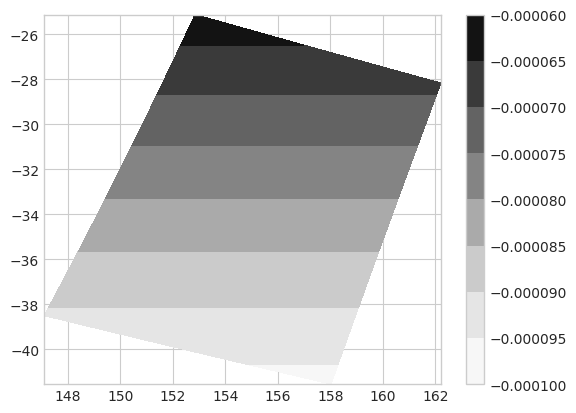

In [6]:
plt.contourf(grid.lon_rho, grid.lat_rho, grid.f)
plt.colorbar()

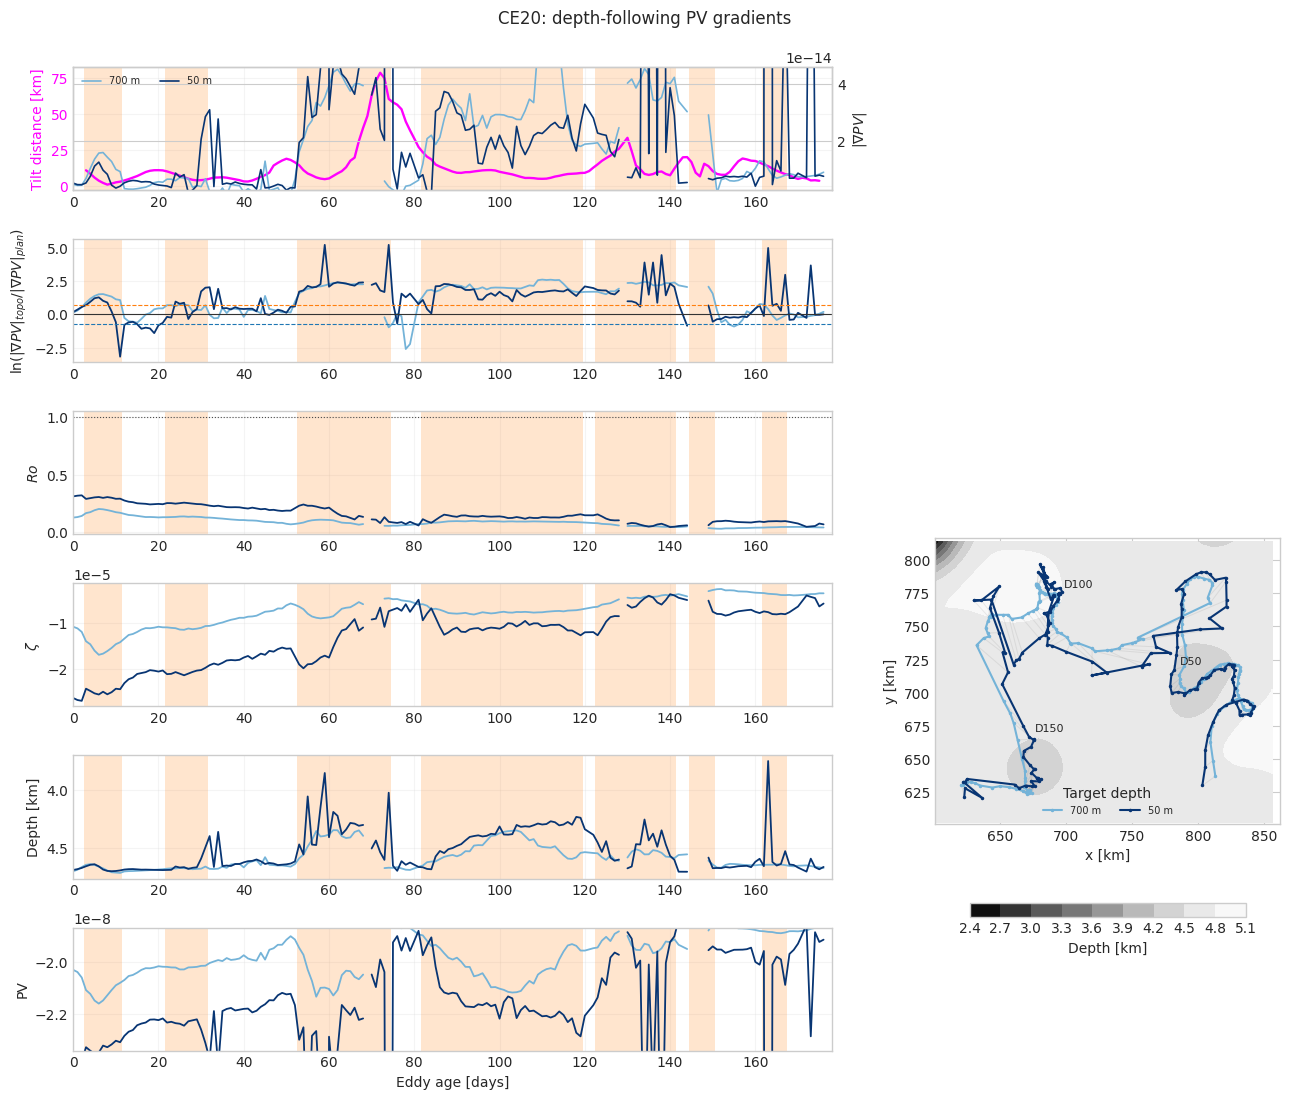

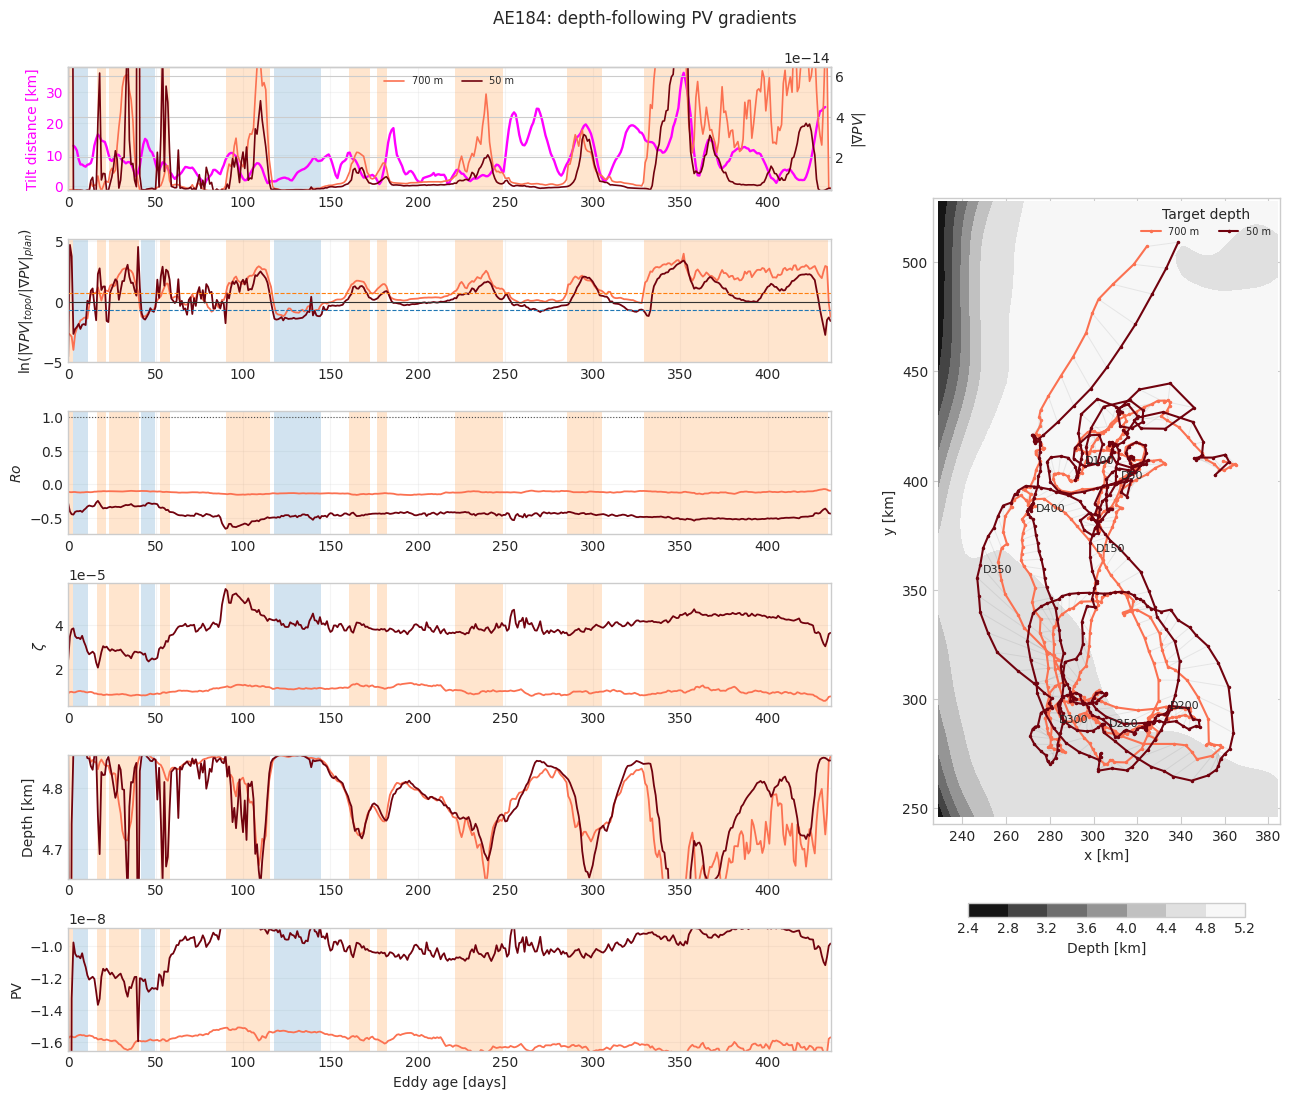

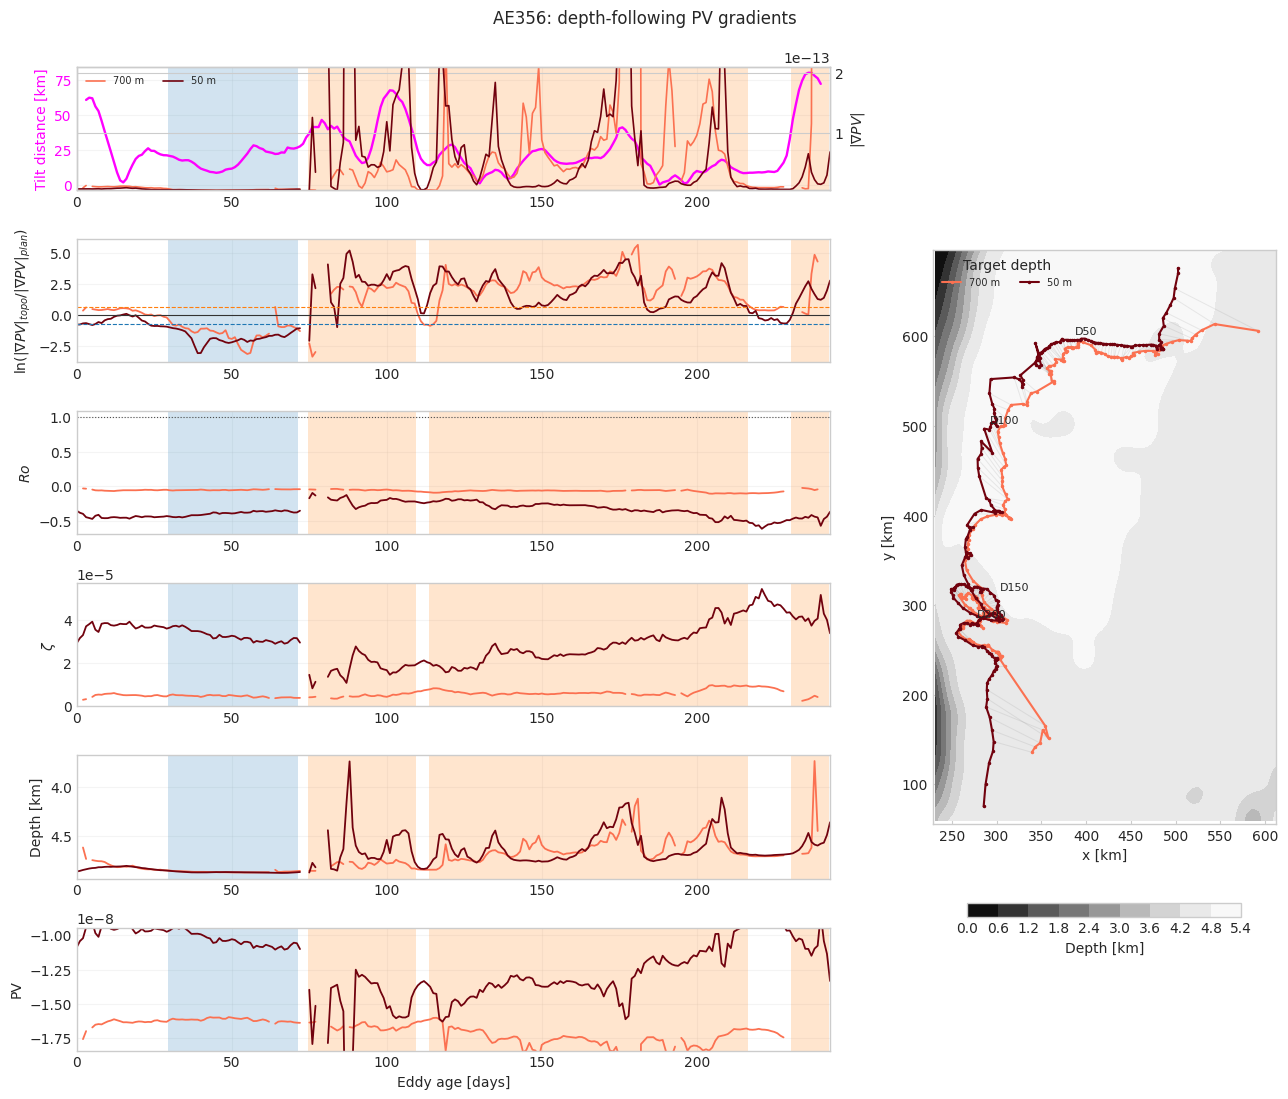

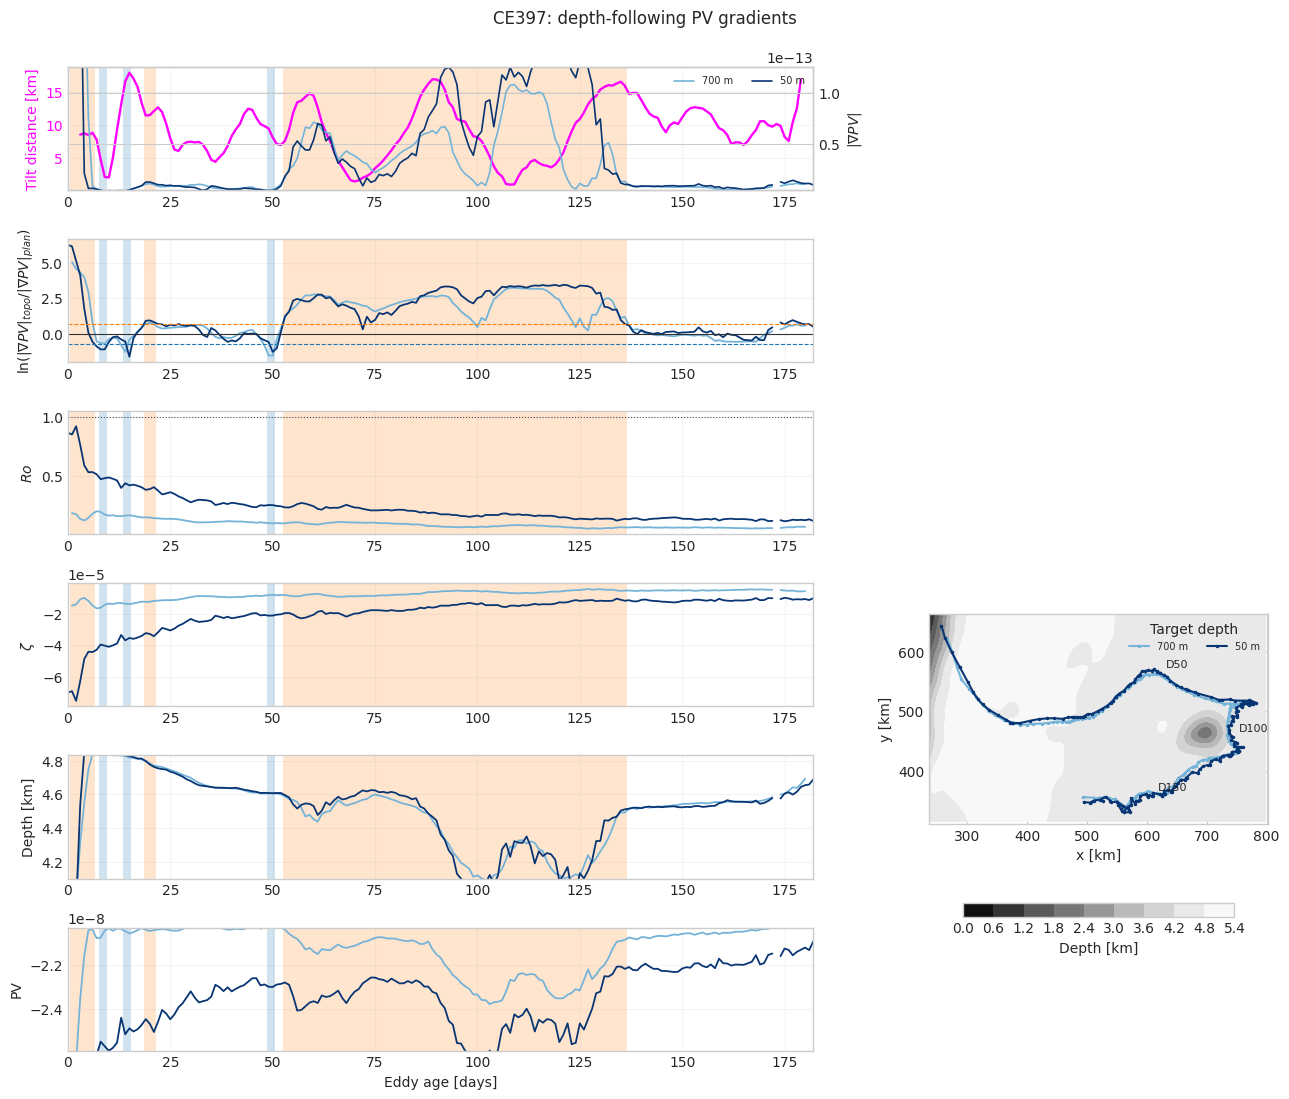

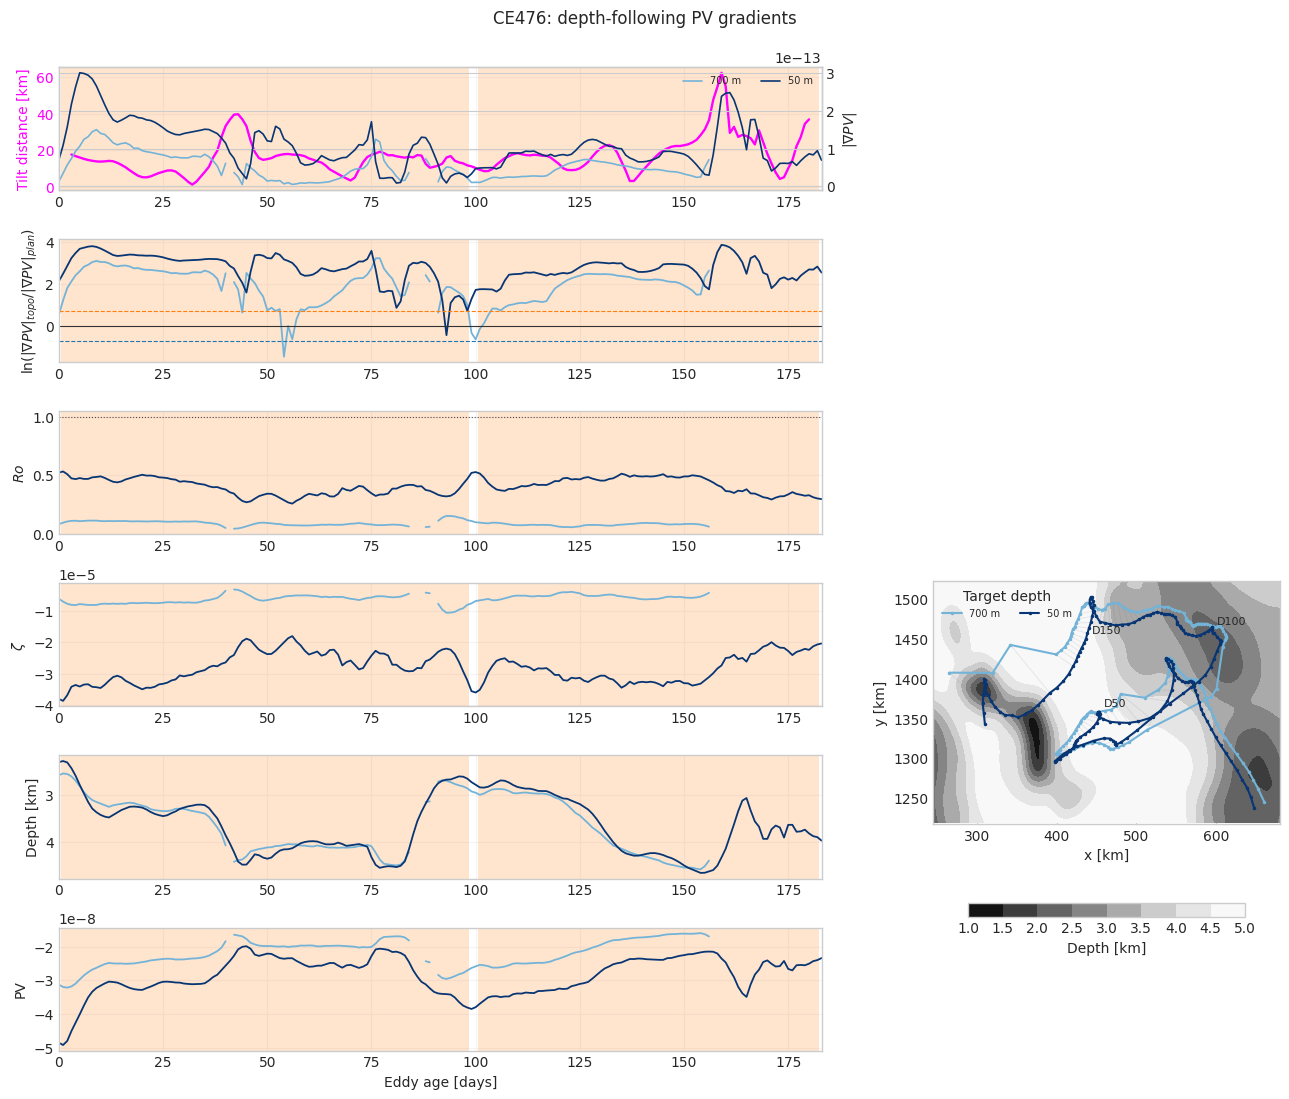

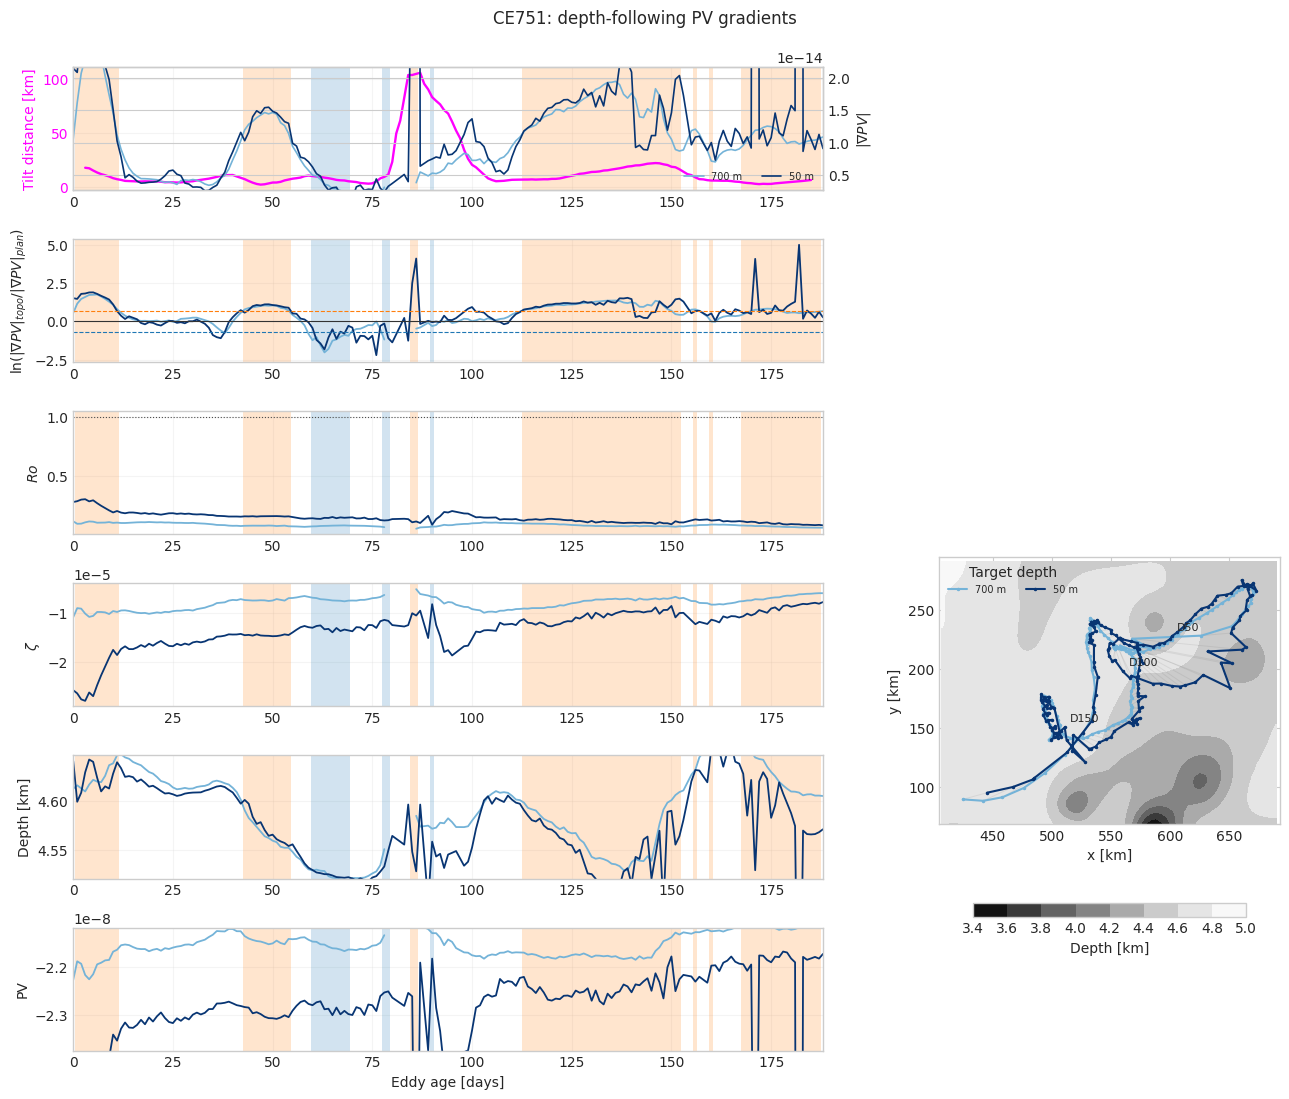

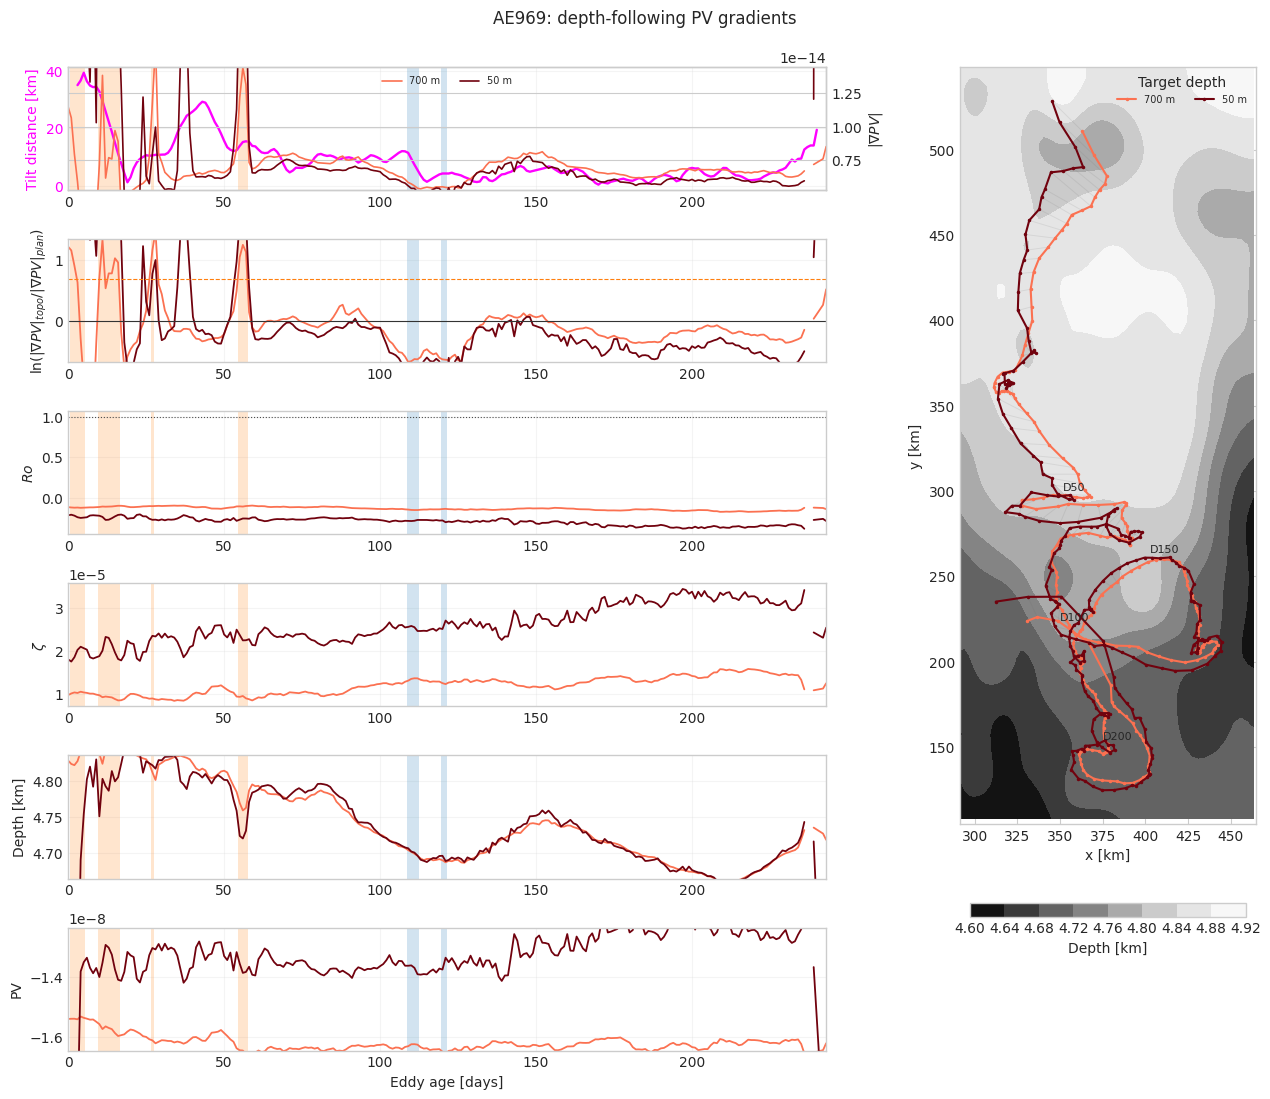

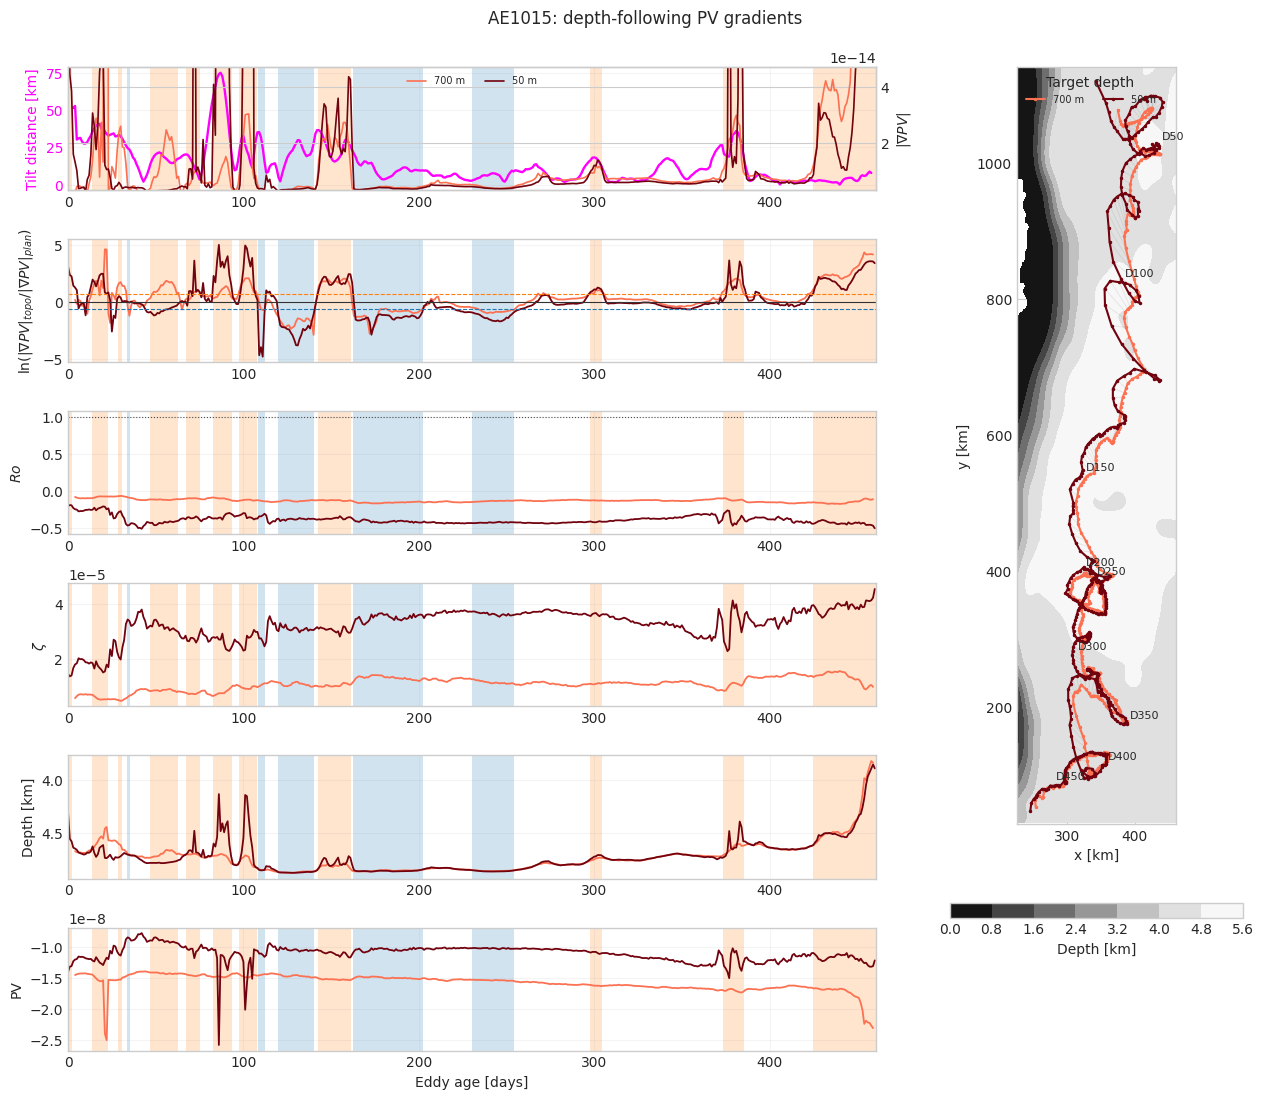

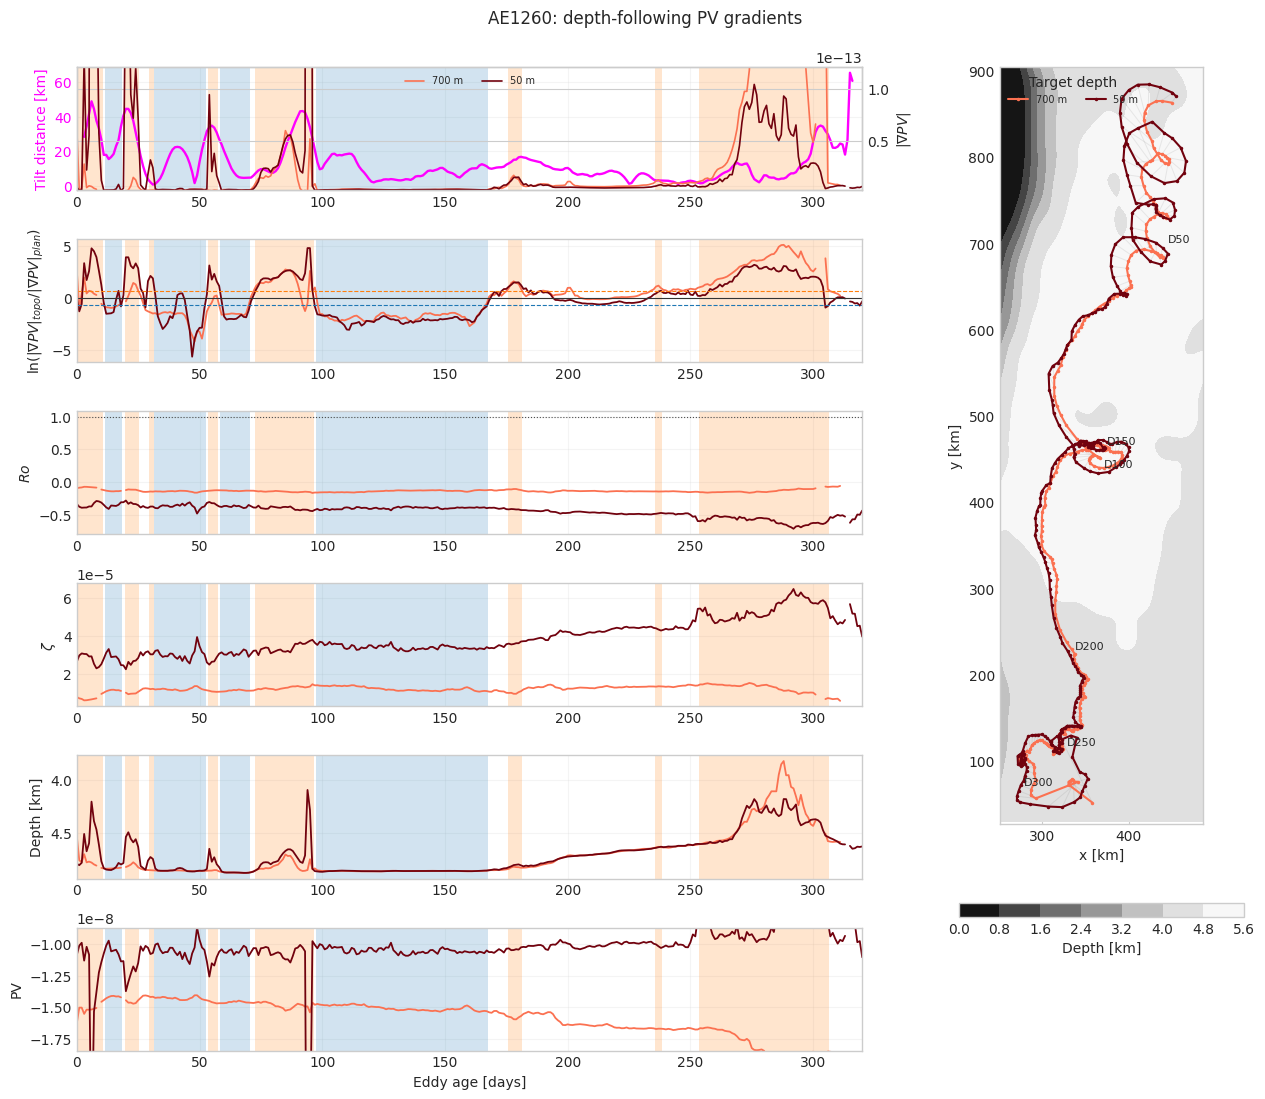

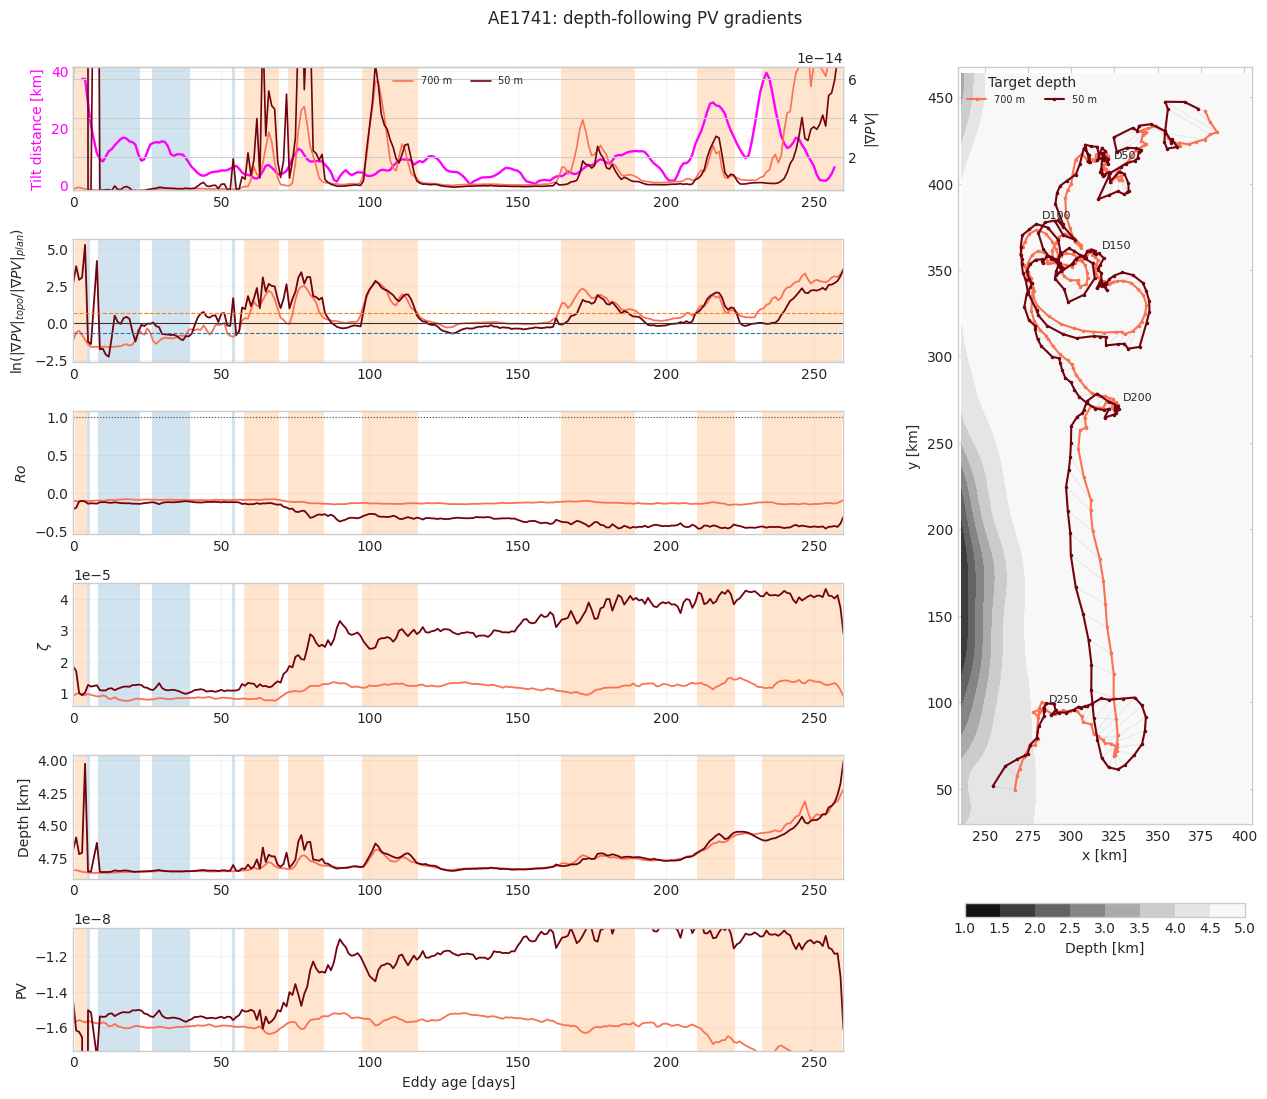

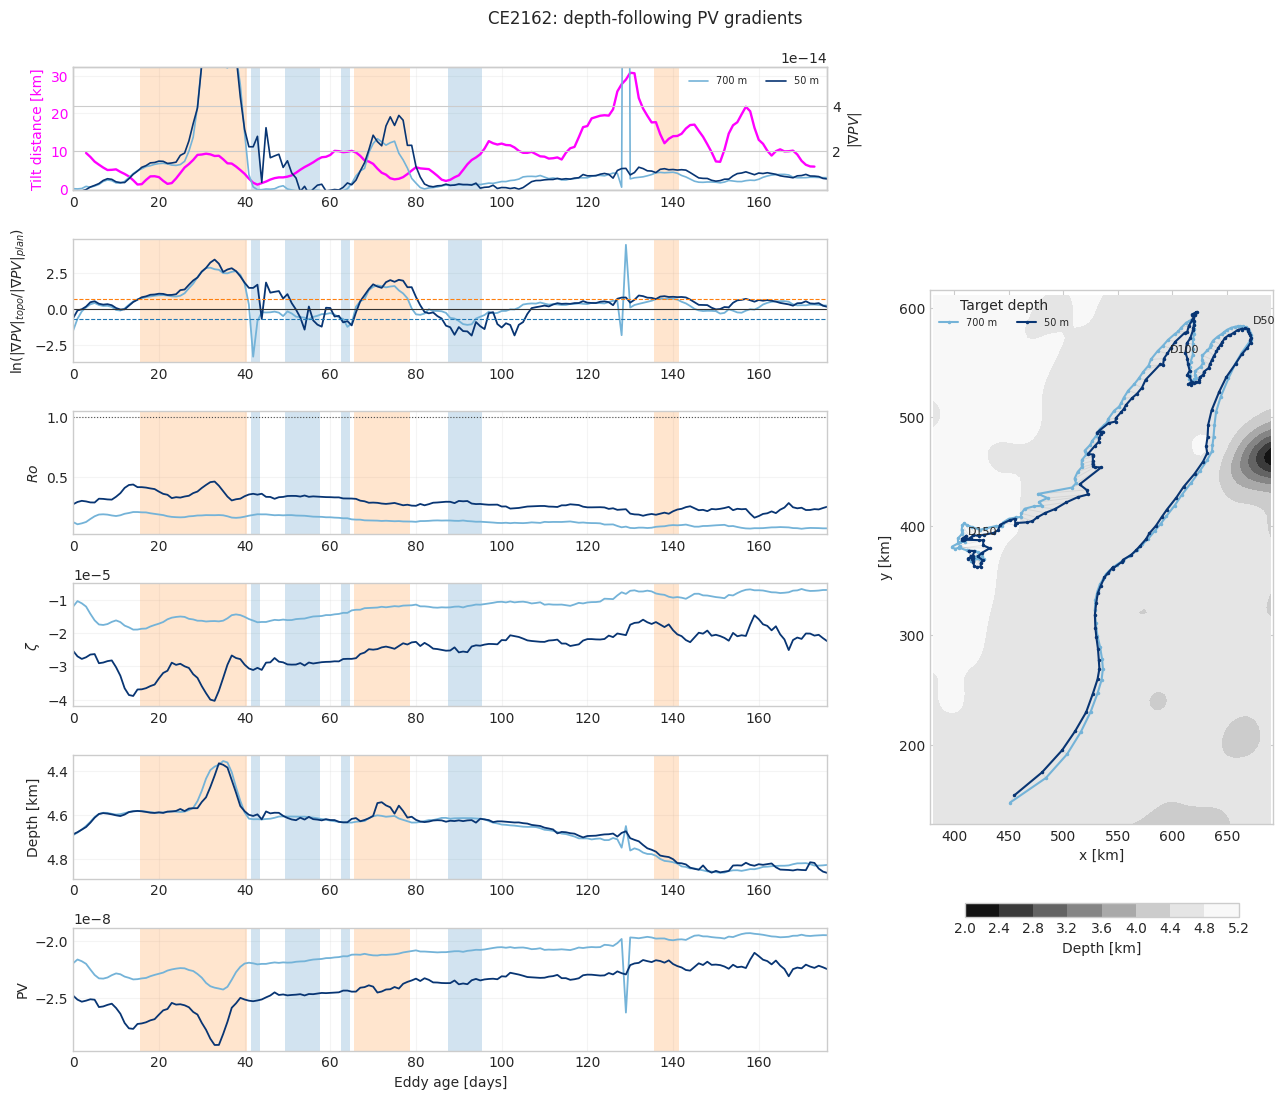

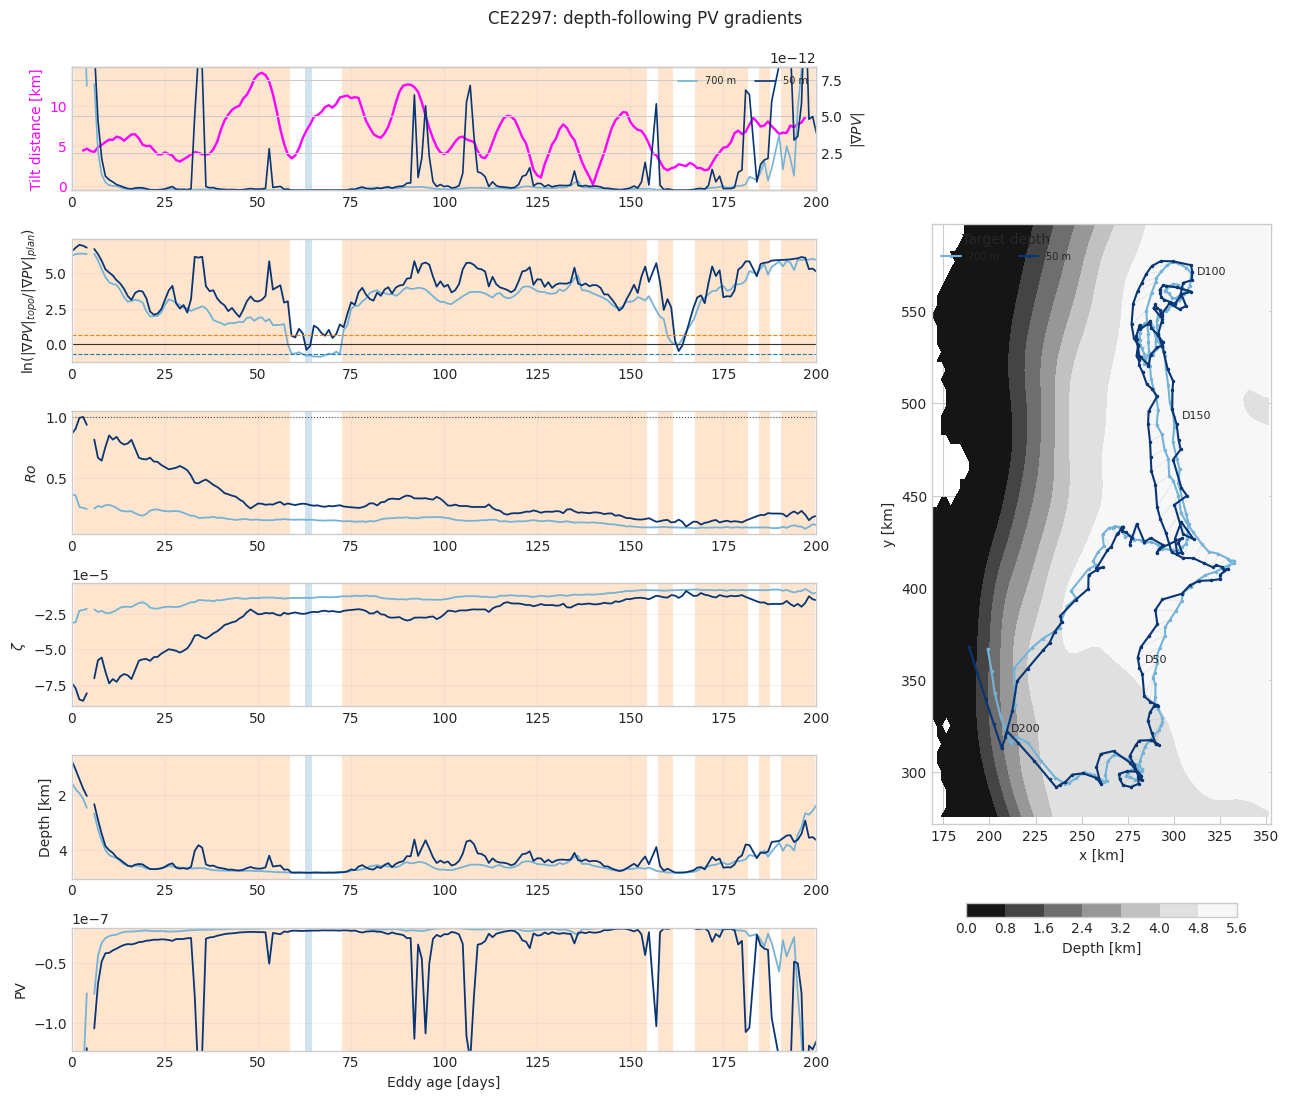

In [23]:
for eddy in selected.Eddy.unique():
    time_plot_depth(eddy, selected, grid)